# Snorkel Demo: Análisis de Sentimiento en Reviews de Productos

**Paper:** *Snorkel: Rapid Training Data Creation with Weak Supervision* (Ratner et al., 2017)

**Machine Learning en Producción — 2026**

---

## Objetivo de la demo

Aplicar el pipeline de **Snorkel** a un dataset real de ~30.000 reviews de productos de e-commerce para clasificar su sentimiento en tres clases (**Negativo / Neutro / Positivo**) **sin etiquetar datos a mano**.

## Pipeline Snorkel

```
Datos sin etiquetar (reviews)
        ↓
  [1] Labeling Functions (heurísticas en Python)
        ↓  (Matriz Λ con votos y conflictos)
  [2] Label Model (generativo)
        ↓  (Etiquetas probabilísticas ỹ)
  [3] Modelo Discriminativo (TF-IDF + LogReg)
        ↓
    Predicciones finales
```

## Ground truth para evaluación

Usamos el `stars` rating (1-5) como ground truth **solo para evaluar** (no para entrenar):
- `1-2 estrellas` → **Negativo**
- `3 estrellas` → **Neutro**
- `4-5 estrellas` → **Positivo**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

!pip install snorkel
from snorkel.labeling import labeling_function, PandasLFApplier, LFAnalysis
from snorkel.labeling.model import LabelModel, MajorityLabelVoter
from snorkel.labeling import filter_unlabeled_dataframe

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Estética
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Reproducibilidad
np.random.seed(42)

print("✅ Setup completo")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 2.7 MB/s eta 0:00:00
✅ Setup completo


---
# **Carga y exploración de datos**

Cargamos el dataset y exploramos su estructura.

In [3]:
# Cargar dataset
df = pd.read_csv('reviews_productos.csv')
df = df.dropna(subset=['user_review']).reset_index(drop=True)
df['user_review_lower'] = df['user_review'].str.lower()

print(f"Total reviews: {len(df):,}")
print(f"Columnas: {df.columns.tolist()}")
print(f"\n Distribución de stars:")
print(df['stars'].value_counts().sort_index())

df.head(5)

Total reviews: 29,611
Columnas: ['name', 'stars', 'user_review', 'user_review_lower']

 Distribución de stars:
stars
1    14836
2     3368
3     4389
4     1810
5     5208
Name: count, dtype: int64


,name,stars,user_review,user_review_lower
0,Mango Importado 1 Unidad,1,No habia,no habia
1,Nectarin Fresh Garden 907 g,1,Mi pedido vino con algunas vencidas,mi pedido vino con algunas vencidas
2,Albahaca Atado,1,Pedi albahscs y me trajeron perejil,pedi albahscs y me trajeron perejil
3,Banana Ecuador,1,Pasada,pasada
4,Aguacate Verde Horti Fresh 1 Unidad,1,Podrido,podrido


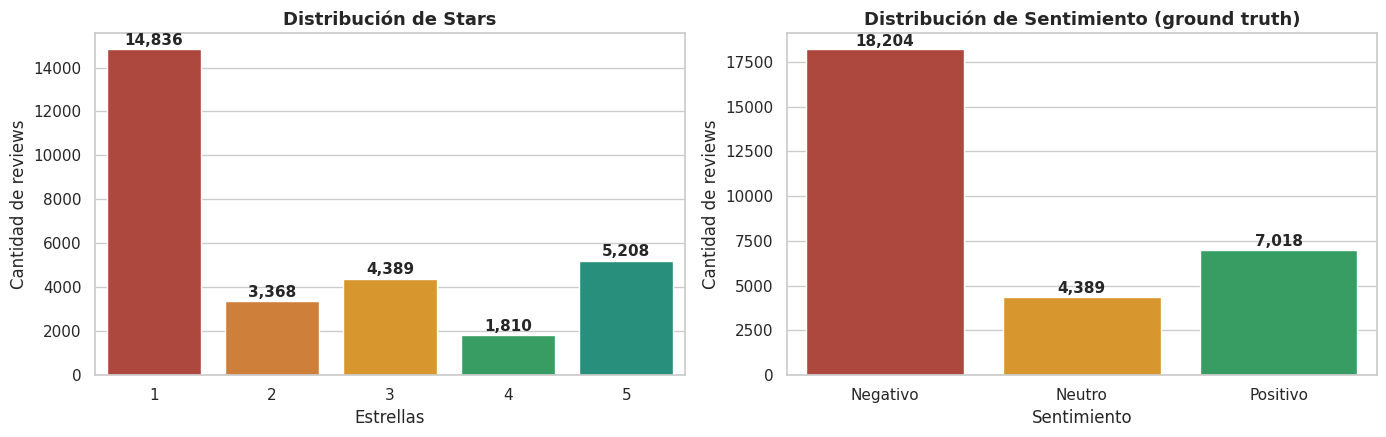


 Clase dominante: Negativo (61.5%) - dataset desbalanceado


In [5]:
# Ground truth: Convertimos el puntaje de stars a sentimiento
ABSTAIN = -1
NEGATIVO = 0
NEUTRO = 1
POSITIVO = 2
LABEL_NAMES = ['Negativo', 'Neutro', 'Positivo']

def star_to_label(s):
    if s <= 2: return NEGATIVO
    if s == 3: return NEUTRO
    return POSITIVO

df['y_true'] = df['stars'].apply(star_to_label)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Distribución por stars
star_counts = df['stars'].value_counts().sort_index()
sns.barplot(x=star_counts.index, y=star_counts.values, ax=axes[0],
            palette=['#c0392b', '#e67e22', '#f39c12', '#27ae60', '#16a085'])
axes[0].set_title('Distribución de Stars', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Estrellas')
axes[0].set_ylabel('Cantidad de reviews')
for i, v in enumerate(star_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Distribución por sentimiento
sent_counts = df['y_true'].value_counts().sort_index()
colors_sent = ['#c0392b', '#f39c12', '#27ae60']
sns.barplot(x=[LABEL_NAMES[i] for i in sent_counts.index],
            y=sent_counts.values, ax=axes[1], palette=colors_sent)
axes[1].set_title('Distribución de Sentimiento (ground truth)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentimiento')
axes[1].set_ylabel('Cantidad de reviews')
for i, v in enumerate(sent_counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n Clase dominante: Negativo ({sent_counts[0]/len(df):.1%}) - dataset desbalanceado")

In [6]:
# Ver ejemplos de cada clase
print("Ejemplos de reviews por clase:\n")
for label_id, name in enumerate(LABEL_NAMES):
    print(f"━━━ {name.upper()} ━━━")
    samples = df[df['y_true'] == label_id]['user_review'].sample(3, random_state=42)
    for r in samples:
        print(f"  • {r[:120]}")
    print()

Ejemplos de reviews por clase:

━━━ NEGATIVO ━━━
  • Mandaron papas negras. Yo pagué por las cepilladas
  • Llegó abierto y se veía que se descongeló y se congeló varias veces
  • Las papas no están frescas

━━━ NEUTRO ━━━
  • Por vencer
  • Estaban un poco aplastados.
  • Mucha grasa

━━━ POSITIVO ━━━
  • En realidad todo perfecto y exquisito. Los felicito por su  buena voluntad. Muchas gracias  Ana Sol.  Hasta una próxima 
  • Me llegó una cápsula reventada
  • Frescas



Detectamos inconsistencias entre el score otorgado y el sentimiento expresado en la review. En lugar de usar el rating como ground truth, Snorkel permite integrar distintas fuentes débiles de supervisión para inferir etiquetas más robustas.

---
# **Escribimos Labeling Functions (LFs)**

Las **Labeling Functions (LFs)** son heurísticas en Python que expresan conocimiento del dominio. Cada LF:

- Recibe una review como input
- Devuelve una etiqueta (`NEGATIVO`, `NEUTRO`, `POSITIVO`)
- O **abstiene** (`ABSTAIN = -1`) si no está segura

**Clave conceptual**: las LFs pueden ser **ruidosas, imprecisas y tener cobertura limitada**. Snorkel se encarga de combinarlas.

In [7]:
# ═══════════════════════════════════════════════
# LFs para detectar NEGATIVO
# ═══════════════════════════════════════════════

NEG_KEYWORDS = [
    'malo', 'horrible', 'pésimo', 'pesimo', 'feo', 'podrido', 'podrida',
    'vencido', 'vencida', 'pasado', 'pasada', 'estropeado', 'estropeada',
    'no sirve', 'no me gustó', 'no me gusto', 'decepcionante',
    'asqueroso', 'bicho', 'gusano', 'no llegó', 'no llego', 'faltó', 'falto',
    'roto', 'rota', 'aplastado', 'aplastada', 'dañado', 'dañada',
    'sucio', 'sucia', 'amargo'
]

@labeling_function()
def lf_neg_keywords(x):
    """Detecta palabras clave negativas en el texto."""
    return NEGATIVO if any(k in x.user_review_lower for k in NEG_KEYWORDS) else ABSTAIN

@labeling_function()
def lf_neg_negacion(x):
    """Detecta negaciones que indican problema de calidad."""
    patterns = ['no está', 'no estan', 'no están', 'no es bueno', 'no es fresco',
                'no es lo que', 'no eran', 'no era lo']
    return NEGATIVO if any(p in x.user_review_lower for p in patterns) else ABSTAIN

@labeling_function()
def lf_neg_mal_estado(x):
    """Menciones explícitas de mal estado."""
    patterns = ['mal estado', 'en mal', 'mala calidad', 'mala condicion',
                'pesima calidad', 'pésima calidad']
    return NEGATIVO if any(p in x.user_review_lower for p in patterns) else ABSTAIN

@labeling_function()
def lf_neg_llego_mal(x):
    """Problemas con la entrega del producto."""
    patterns = ['vino mal', 'vino feo', 'vino podrido', 'llego mal', 'llegó mal',
                'llegaron mal', 'me mandaron otra', 'me mandaron otro',
                'no era lo que', 'no es lo que pedi']
    return NEGATIVO if any(p in x.user_review_lower for p in patterns) else ABSTAIN

@labeling_function()
def lf_neg_una_palabra(x):
    """Reviews de una sola palabra negativa (ej: 'Pasada', 'Feo')."""
    text = x.user_review.strip()
    if len(text.split()) == 1 and len(text) > 3:
        neg_words = ['pasado', 'pasada', 'feo', 'fea', 'malo', 'mala',
                     'podrido', 'podrida', 'duro', 'dura', 'amargo',
                     'amarga', 'blando', 'blanda', 'verde', 'verdes']
        if text.lower() in neg_words:
            return NEGATIVO
    return ABSTAIN

print("5 LFs negativas definidas")

5 LFs negativas definidas


In [8]:
# ═══════════════════════════════════════════════
# LFs para detectar POSITIVO
# ═══════════════════════════════════════════════

POS_KEYWORDS = [
    'excelente', 'perfecto', 'perfecta', 'delicioso', 'deliciosa',
    'buenísimo', 'buenisimo', 'buenísima', 'buenisima', 'riquísimo', 'riquisimo',
    'recomiendo', 'recomendable', 'espectacular', 'hermoso', 'hermosa',
    'impecable', 'divino', 'divina', 'genial', 'increible', 'increíble',
    'me encantó', 'me encanto', 'cumplió', 'cumplio'
]

@labeling_function()
def lf_pos_keywords(x):
    """Detecta palabras clave positivas."""
    return POSITIVO if any(k in x.user_review_lower for k in POS_KEYWORDS) else ABSTAIN

@labeling_function()
def lf_pos_muy_bueno(x):
    """Construcciones 'muy + adjetivo positivo'."""
    patterns = ['muy bueno', 'muy buena', 'muy buenos', 'muy buenas',
                'muy rico', 'muy rica', 'muy fresco', 'muy fresca',
                'muy lindo', 'muy linda', 'super bueno', 'súper bueno',
                'super rico', 'súper rico']
    return POSITIVO if any(p in x.user_review_lower for p in patterns) else ABSTAIN

@labeling_function()
def lf_pos_todo_ok(x):
    """Expresiones de satisfacción general."""
    patterns = ['todo ok', 'todo bien', 'todo perfecto', 'todo excelente',
                'llegó bien', 'llego bien', 'buen estado', 'buena calidad',
                'en perfecto estado', 'buen producto', 'buena presentacion',
                'buena presentación']
    return POSITIVO if any(p in x.user_review_lower for p in patterns) else ABSTAIN

@labeling_function()
def lf_pos_exclamacion(x):
    """Exclamaciones con palabras positivas."""
    if '!' in x.user_review:
        if any(k in x.user_review_lower for k in ['bueno', 'buena', 'rico',
                                                     'rica', 'los mejores']):
            return POSITIVO
    return ABSTAIN

@labeling_function()
def lf_pos_fresco(x):
    """Mención de frescura positiva (sin negación previa)."""
    text = x.user_review_lower
    if 'fresco' in text or 'fresca' in text or 'frescos' in text or 'frescas' in text:
        # Verificar que no haya negación
        if 'no ' not in text[:max(0, text.find('fresc'))]:
            return POSITIVO
    return ABSTAIN

print("5 LFs positivas definidas")

5 LFs positivas definidas


In [9]:
# ═══════════════════════════════════════════════
# LFs para detectar NEUTRO
# ═══════════════════════════════════════════════

@labeling_function()
def lf_neutro_mixto(x):
    """Reviews con elementos positivos y conectores de contraste."""
    text = x.user_review_lower
    has_pos = any(k in text for k in ['bueno', 'buena', 'rico', 'rica'])
    has_contrast = any(k in text for k in ['pero', 'aunque'])
    return NEUTRO if (has_pos and has_contrast) else ABSTAIN

@labeling_function()
def lf_neutro_un_poco(x):
    """Expresiones que suavizan opinión (tibias)."""
    patterns = ['un poco', 'medio ', 'no tan', 'regular',
                'más o menos', 'mas o menos', 'ni muy', 'ni tan']
    return NEUTRO if any(p in x.user_review_lower for p in patterns) else ABSTAIN

@labeling_function()
def lf_neutro_aceptable(x):
    """Expresiones de aceptación sin entusiasmo."""
    patterns = ['zafa', 'aceptable', 'está bien', 'esta bien', 'pasable',
                'cumple', 'normal']
    return NEUTRO if any(p in x.user_review_lower for p in patterns) else ABSTAIN

print("3 LFs neutras definidas")

# Lista completa de LFs
lfs = [
    lf_neg_keywords, lf_neg_negacion, lf_neg_mal_estado, lf_neg_llego_mal,
    lf_neg_una_palabra,
    lf_pos_keywords, lf_pos_muy_bueno, lf_pos_todo_ok,
    lf_pos_exclamacion, lf_pos_fresco,
    lf_neutro_mixto, lf_neutro_un_poco, lf_neutro_aceptable
]
print(f"\nTotal LFs: {len(lfs)}")

3 LFs neutras definidas

Total LFs: 13


---
# **Aplicamos las LFs sobre los datos**

Dividimos el dataset en train (80%) y test (20%), y aplicamos las LFs para generar la matriz Λ de votos.

In [11]:
# Split train/test
idx = np.random.permutation(len(df))
split = int(0.8 * len(df))
df_train = df.iloc[idx[:split]].reset_index(drop=True)
df_test = df.iloc[idx[split:]].reset_index(drop=True)

print(f"Train: {len(df_train):,}")
print(f"Test:  {len(df_test):,}")

# Aplicar LFs
print("\nAplicando LFs sobre train...")
applier = PandasLFApplier(lfs=lfs)
L_train = applier.apply(df=df_train)

print("Aplicando LFs sobre test...")
L_test = applier.apply(df=df_test)

print(f"\nShape matriz Λ_train: {L_train.shape}")
print(f"Shape matriz Λ_test:  {L_test.shape}")

Train: 23,688
Test:  5,923

Aplicando LFs sobre train...


100%|██████████| 23688/23688 [00:26<00:00, 888.23it/s]


Aplicando LFs sobre test...


100%|██████████| 5923/5923 [00:04<00:00, 1440.43it/s]


Shape matriz Λ_train: (23688, 13)
Shape matriz Λ_test:  (5923, 13)


### 📈 Análisis de cada Labeling Function

Snorkel provee la clase `LFAnalysis` que nos dice:
- **Coverage**: % de ejemplos que la LF etiqueta (no abstiene)
- **Overlaps**: % donde la LF coincide con otras LFs
- **Conflicts**: % donde la LF **difiere** de otras LFs

Nota: no necesitamos ground truth para este análisis — Snorkel aprende la calidad de las LFs viendo sus acuerdos/desacuerdos.

In [12]:
# Análisis de las LFs (sin usar ground truth)
lf_names = [lf.name for lf in lfs]
analysis = LFAnalysis(L=L_train, lfs=lfs).lf_summary()
analysis.index = lf_names
analysis_display = analysis[['Polarity', 'Coverage', 'Overlaps', 'Conflicts']].copy()
analysis_display['Coverage'] = (analysis_display['Coverage'] * 100).round(2)
analysis_display['Overlaps'] = (analysis_display['Overlaps'] * 100).round(2)
analysis_display['Conflicts'] = (analysis_display['Conflicts'] * 100).round(2)
analysis_display.columns = ['Polaridad', 'Coverage (%)', 'Overlaps (%)', 'Conflicts (%)']
analysis_display

,Polaridad,Coverage (%),Overlaps (%),Conflicts (%)
lf_neg_keywords,[0],18.78,2.08,0.87
lf_neg_negacion,[0],2.10,0.59,0.30
lf_neg_mal_estado,[0],4.14,0.62,0.09
lf_neg_llego_mal,[0],0.52,0.35,0.02
lf_neg_una_palabra,[0],1.37,0.38,0.00
lf_pos_keywords,[2],3.38,0.50,0.10
lf_pos_muy_bueno,[2],2.09,0.95,0.19
lf_pos_todo_ok,[2],2.73,0.89,0.23
lf_pos_exclamacion,[2],0.16,0.12,0.03
lf_pos_fresco,[2],3.21,0.76,0.11


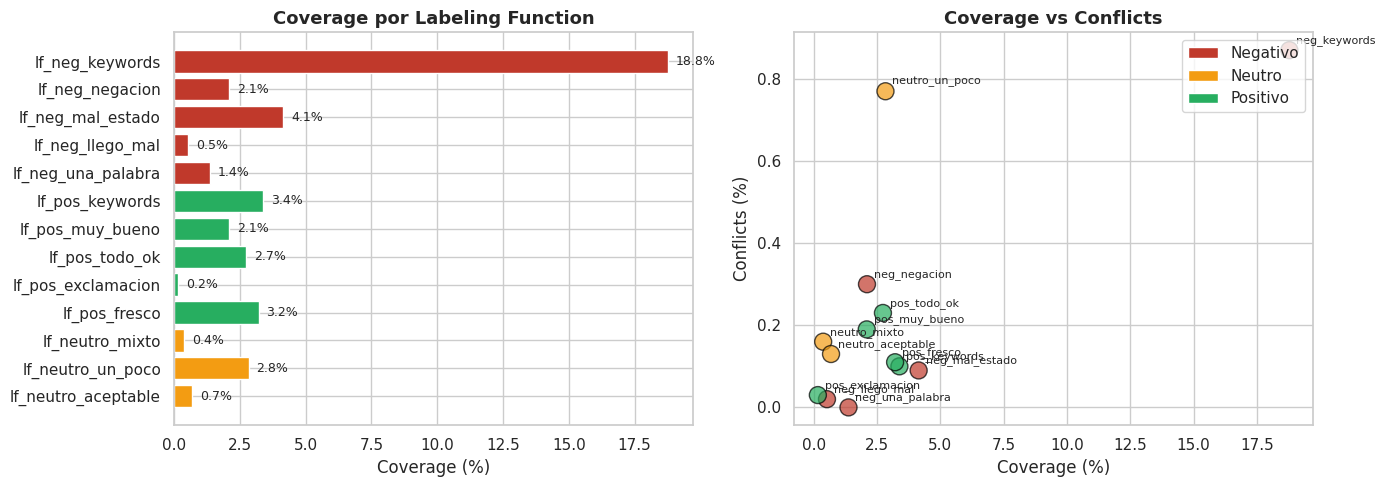


Coverrtura total (al menos una LF vota): 38.0%


In [14]:
# Visualización: coverage y conflicts por LF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coverage con color por polaridad
polarity_colors = {0: '#c0392b', 1: '#f39c12', 2: '#27ae60'}
colors = [polarity_colors[analysis.iloc[i]['Polarity'][0]] for i in range(len(lfs))]

ax = axes[0]
bars = ax.barh(lf_names, analysis_display['Coverage (%)'], color=colors)
ax.set_xlabel('Coverage (%)')
ax.set_title('Coverage por Labeling Function', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(analysis_display['Coverage (%)']):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

# Coverage vs Conflicts
ax = axes[1]
ax.scatter(analysis_display['Coverage (%)'], analysis_display['Conflicts (%)'],
           c=colors, s=150, alpha=0.7, edgecolors='black', linewidth=1)
for i, name in enumerate(lf_names):
    ax.annotate(name.replace('lf_', ''),
                (analysis_display['Coverage (%)'].iloc[i],
                 analysis_display['Conflicts (%)'].iloc[i]),
                fontsize=8, xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('Coverage (%)')
ax.set_ylabel('Conflicts (%)')
ax.set_title('Coverage vs Conflicts', fontsize=13, fontweight='bold')

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#c0392b', label='Negativo'),
    Patch(facecolor='#f39c12', label='Neutro'),
    Patch(facecolor='#27ae60', label='Positivo')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

coverage_total = (L_train != ABSTAIN).any(axis=1).mean()
print(f"\nCoverrtura total (al menos una LF vota): {coverage_total:.1%}")

---
# **Baseline: Voto Mayoritario**

Primero probamos la estrategia más simple: **Voto Mayoritario** — para cada ejemplo, la clase mayoritaria entre las LFs que votaron.

Esto es el **baseline** contra el que compararemos el modelo generativo de Snorkel.

In [15]:
# Voto Mayoritario
mv = MajorityLabelVoter(cardinality=3)
preds_mv = mv.predict(L=L_test, tie_break_policy="abstain")

# Evaluación solo sobre ejemplos donde MV no abstuvo
mask_mv = preds_mv != ABSTAIN
acc_mv = accuracy_score(df_test.loc[mask_mv, 'y_true'], preds_mv[mask_mv])
f1_mv = f1_score(df_test.loc[mask_mv, 'y_true'], preds_mv[mask_mv], average='macro')
coverage_mv = mask_mv.sum() / len(df_test)

print("🗳️  MAJORITY VOTE")
print(f"   Coverage:  {coverage_mv:.1%}")
print(f"   Accuracy:  {acc_mv:.3f}")
print(f"   F1 macro:  {f1_mv:.3f}")

🗳️  MAJORITY VOTE
   Coverage:  37.1%
   Accuracy:  0.828
   F1 macro:  0.683


---
## Modelo Generativo de Snorkel (Label Model)

El **Label Model** es el corazón de Snorkel. Aprende **sin ground truth**:
- La **precisión** de cada LF (basándose en acuerdos/desacuerdos)
- La **correlación** entre LFs

Y produce etiquetas probabilísticas ỹ ∈ [0,1] más inteligentes que un simple voto mayoritario.

In [17]:
# Entrenar Label Model
label_model = LabelModel(cardinality=3, verbose=False)
label_model.fit(L_train=L_train, n_epochs=500, log_freq=100, seed=42)

# Predecir
preds_lm = label_model.predict(L=L_test, tie_break_policy="abstain")
mask_lm = preds_lm != ABSTAIN
acc_lm = accuracy_score(df_test.loc[mask_lm, 'y_true'], preds_lm[mask_lm])
f1_lm = f1_score(df_test.loc[mask_lm, 'y_true'], preds_lm[mask_lm], average='macro')
coverage_lm = mask_lm.sum() / len(df_test)

print("LABEL MODEL (Generativo)")
print(f"   Coverage:  {coverage_lm:.1%}")
print(f"   Accuracy:  {acc_lm:.3f}")
print(f"   F1 macro:  {f1_lm:.3f}")

# Ver las precisiones aprendidas
print("\nPrecisiones aprendidas por el Label Model (sin ground truth):")
learned_weights = label_model.get_weights()
for name, w in zip(lf_names, learned_weights):
    bar = '█' * int(w * 20)
    print(f"   {name:30s} {bar} {w:.3f}")

100%|██████████| 500/500 [00:00<00:00, 667.12epoch/s]


LABEL MODEL (Generativo)
   Coverage:  38.4%
   Accuracy:  0.779
   F1 macro:  0.643

Precisiones aprendidas por el Label Model (sin ground truth):
   lf_neg_keywords                ██████████ 0.534
   lf_neg_negacion                █████ 0.260
   lf_neg_mal_estado              ███████ 0.382
   lf_neg_llego_mal               ████████████████ 0.849
   lf_neg_una_palabra             █████████████ 0.652
   lf_pos_keywords                █████████████ 0.672
   lf_pos_muy_bueno               ███████████████ 0.796
   lf_pos_todo_ok                 ██████████████ 0.710
   lf_pos_exclamacion             ███████████████████ 0.962
   lf_pos_fresco                  █████████████ 0.700
   lf_neutro_mixto                ███████████ 0.594
   lf_neutro_un_poco              █████████ 0.481
   lf_neutro_aceptable            ███████████ 0.583


En este experimento, Majority Vote superó al LabelingModel, probablemente porque las reglas eran pocas, similares o con calidad comparable. En escenarios más complejos, modelar confiabilidad suele aportar más valor.

---
# **Modelo Discriminativo (el paso que generaliza)**

Este el punto clave de Snorkel: usamos las etiquetas probabilísticas ỹ del Label Model para entrenar un **clasificador normal** (TF-IDF + Logistic Regression).

**¿Por qué es importante este paso?**

El Label Model solo puede etiquetar lo que las LFs cubren (~38% de los datos). El discriminativo:

- ✅ Aprende **patrones del texto crudo** que las LFs nunca vieron
- ✅ Logra **100% de coverage** en datos nuevos
- ✅ Generaliza a ejemplos que ninguna LF podía cubrir

In [19]:
# Generar labels probabilísticos con Label Model
probs_train = label_model.predict_proba(L=L_train)

# Filtrar ejemplos donde ninguna LF votó (no podemos aprender de ellos)
df_train_filt, probs_train_filt = filter_unlabeled_dataframe(
    X=df_train, y=probs_train, L=L_train
)
print(f"Train tras filtrar no-etiquetados: {len(df_train_filt):,} de {len(df_train):,}")

# Vectorización TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                              min_df=3, max_df=0.9)
X_train = vectorizer.fit_transform(df_train_filt['user_review'])
X_test = vectorizer.transform(df_test['user_review'])

# Hard labels a partir de las probabilidades
y_train_hard = probs_train_filt.argmax(axis=1)

# Entrenar
clf = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', C=1.0)
clf.fit(X_train, y_train_hard)

# Evaluar
preds_disc = clf.predict(X_test)
acc_disc = accuracy_score(df_test['y_true'], preds_disc)
f1_disc = f1_score(df_test['y_true'], preds_disc, average='macro')

print("\n MODELO DISCRIMINATIVO (TF-IDF + LogReg)")
print(f"   Coverage:  100% (predice en todos los datos)")
print(f"   Accuracy:  {acc_disc:.3f}")
print(f"   F1 macro:  {f1_disc:.3f}")

print("\n Classification report:")
print(classification_report(df_test['y_true'], preds_disc,
                            target_names=LABEL_NAMES, digits=3))

Train tras filtrar no-etiquetados: 9,002 de 23,688

 MODELO DISCRIMINATIVO (TF-IDF + LogReg)
   Coverage:  100% (predice en todos los datos)
   Accuracy:  0.665
   F1 macro:  0.523

 Classification report:
              precision    recall  f1-score   support

    Negativo      0.766     0.803     0.784      3598
      Neutro      0.287     0.145     0.192       920
    Positivo      0.544     0.652     0.593      1405

    accuracy                          0.665      5923
   macro avg      0.532     0.533     0.523      5923
weighted avg      0.639     0.665     0.647      5923



---
# **Comparación: ¿Cuánto nos acercamos al oracle supervisado?**

Para calibrar qué tan buenos son los resultados, entrenamos un modelo **idéntico pero con los labels reales** (stars). Es el **techo teórico** contra el que comparamos.

In [21]:
# Baseline supervisado: mismo modelo pero con labels reales
X_train_sup = vectorizer.transform(df_train['user_review'])
clf_sup = LogisticRegression(max_iter=1000, random_state=42,
                              class_weight='balanced', C=1.0)
clf_sup.fit(X_train_sup, df_train['y_true'])
preds_sup = clf_sup.predict(X_test)

acc_sup = accuracy_score(df_test['y_true'], preds_sup)
f1_sup = f1_score(df_test['y_true'], preds_sup, average='macro')

print("SUPERVISADO (con labels reales - oracle)")
print(f"   Accuracy:  {acc_sup:.3f}")
print(f"   F1 macro:  {f1_sup:.3f}")
print(f"\nGap Snorkel vs Supervisado: {(f1_sup - f1_disc)*100:.1f} puntos F1")

SUPERVISADO (con labels reales - oracle)
   Accuracy:  0.699
   F1 macro:  0.659

Gap Snorkel vs Supervisado: 13.6 puntos F1


---
# **Comparación final: los 4 approaches**

Resumimos todo en una tabla y visualización.

In [22]:
# Tabla comparativa
results = pd.DataFrame({
    'Approach': ['Majority Vote', 'Label Model (Gen)', 'Disc. Model (Snorkel)', 'Supervisado (oracle)'],
    'Coverage': [f'{coverage_mv:.1%}', f'{coverage_lm:.1%}', '100%', '100%'],
    'Accuracy': [acc_mv, acc_lm, acc_disc, acc_sup],
    'F1 macro': [f1_mv, f1_lm, f1_disc, f1_sup],
    'Datos etiquetados a mano': ['❌ 0', '❌ 0', '❌ 0', '✅ 23.701']
})

results_display = results.copy()
results_display['Accuracy'] = results_display['Accuracy'].apply(lambda x: f'{x:.3f}')
results_display['F1 macro'] = results_display['F1 macro'].apply(lambda x: f'{x:.3f}')
results_display

,Approach,Coverage,Accuracy,F1 macro,Datos etiquetados a mano
0,Majority Vote,37.1%,0.828,0.683,❌ 0
1,Label Model (Gen),38.4%,0.779,0.643,❌ 0
2,Disc. Model (Snorkel),100%,0.665,0.523,❌ 0
3,Supervisado (oracle),100%,0.699,0.659,✅ 23.701


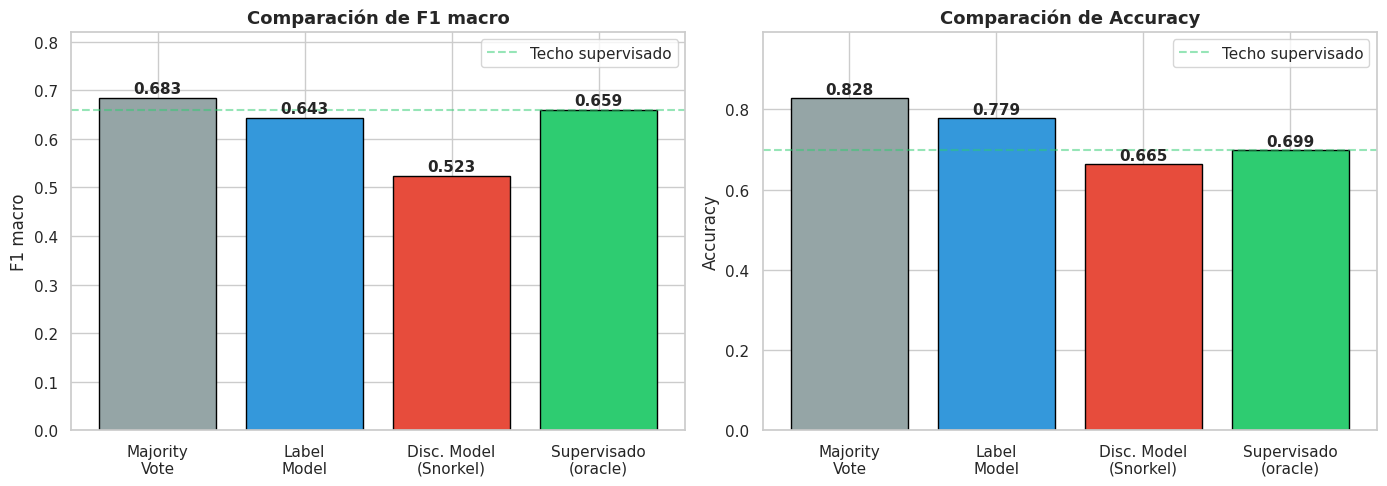


El modelo discriminativo de Snorkel alcanza el 79.4% del F1 del supervisado
   sin haber etiquetado ni un solo ejemplo a mano.


In [24]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

approaches = ['Majority\nVote', 'Label\nModel', 'Disc. Model\n(Snorkel)', 'Supervisado\n(oracle)']
f1_scores = [f1_mv, f1_lm, f1_disc, f1_sup]
acc_scores = [acc_mv, acc_lm, acc_disc, acc_sup]
colors_comp = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71']

# F1
ax = axes[0]
bars = ax.bar(approaches, f1_scores, color=colors_comp, edgecolor='black', linewidth=1)
ax.set_ylabel('F1 macro')
ax.set_title('Comparación de F1 macro', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(f1_scores) * 1.2)
ax.axhline(y=f1_sup, color='#2ecc71', linestyle='--', alpha=0.5, label='Techo supervisado')
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', fontweight='bold')
ax.legend()

# Accuracy
ax = axes[1]
bars = ax.bar(approaches, acc_scores, color=colors_comp, edgecolor='black', linewidth=1)
ax.set_ylabel('Accuracy')
ax.set_title('Comparación de Accuracy', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(acc_scores) * 1.2)
ax.axhline(y=acc_sup, color='#2ecc71', linestyle='--', alpha=0.5, label='Techo supervisado')
for bar, score in zip(bars, acc_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nEl modelo discriminativo de Snorkel alcanza el {f1_disc/f1_sup*100:.1f}% del F1 del supervisado")
print(f"   sin haber etiquetado ni un solo ejemplo a mano.")

### 🎨 Matrices de confusión

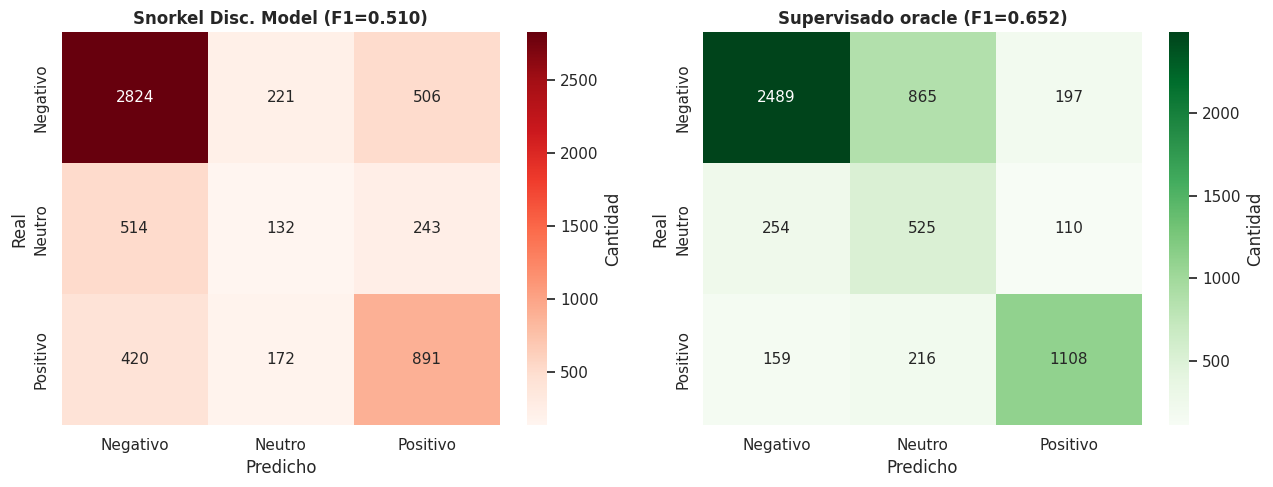

In [ ]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Snorkel
cm_disc = confusion_matrix(df_test['y_true'], preds_disc)
sns.heatmap(cm_disc, annot=True, fmt='d', cmap='Reds',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[0],
            cbar_kws={'label': 'Cantidad'})
axes[0].set_title(f'Snorkel Disc. Model (F1={f1_disc:.3f})', fontweight='bold')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# Supervisado
cm_sup = confusion_matrix(df_test['y_true'], preds_sup)
sns.heatmap(cm_sup, annot=True, fmt='d', cmap='Greens',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[1],
            cbar_kws={'label': 'Cantidad'})
axes[1].set_title(f'Supervisado oracle (F1={f1_sup:.3f})', fontweight='bold')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

---
# **El aporte clave: generalización más allá de las LFs**


Buscamos ejemplos donde **ninguna LF votó** (todas abstuvieron), pero el modelo discriminativo **sí los clasificó correctamente**. Esto demuestra que el modelo **aprendió patrones que ninguna LF cubrió explícitamente**.

In [26]:
# Detectar ejemplos donde ninguna LF votó en test
no_lf_voted = (L_test == ABSTAIN).all(axis=1)
print(f"Ejemplos en test donde ninguna LF votó: {no_lf_voted.sum():,} ({no_lf_voted.mean():.1%})")

# De esos, cuántos clasificó correctamente el modelo discriminativo
correct_on_uncovered = (preds_disc[no_lf_voted] == df_test.loc[no_lf_voted, 'y_true']).mean()
print(f"De ellos, el discriminativo acierta en el {correct_on_uncovered:.1%}")
print(f"   (sin haber visto ni un solo label a mano)")

# Mostrar algunos ejemplos de generalización exitosa
uncovered_correct = no_lf_voted & (preds_disc == df_test['y_true'])
print("\nEjemplos donde el discriminativo generalizó exitosamente:\n")
sample_gen = df_test[uncovered_correct].sample(8, random_state=42)
for _, row in sample_gen.iterrows():
    true_label = LABEL_NAMES[row['y_true']]
    pred_label = LABEL_NAMES[preds_disc[row.name]] if row.name < len(preds_disc) else 'N/A'
    icon = {'Negativo': '🔴', 'Neutro': '🟡', 'Positivo': '🟢'}[true_label]
    print(f"{icon} [{true_label}]  \"{row['user_review'][:100]}\"")

Ejemplos en test donde ninguna LF votó: 3,651 (61.6%)
De ellos, el discriminativo acierta en el 59.7%
   (sin haber visto ni un solo label a mano)

Ejemplos donde el discriminativo generalizó exitosamente:

🟢 [Positivo]  "Buenos tomates"
🔴 [Negativo]  "Tiene olor abonvado una de las piezas"
🔴 [Negativo]  "machucado"
🔴 [Negativo]  "Toda marchita"
🟡 [Neutro]  "verdes pero bien"
🔴 [Negativo]  "Vinieron verdes"
🔴 [Negativo]  "Pedido equivocado!"
🟢 [Positivo]  "Calidad"


---
## **Conclusiones de la demo**

### Lo que mostramos

1. **Escribimos 13 Labeling Functions** en ~100 líneas de Python que capturan heurísticas lingüísticas del español.

2. **Snorkel combinó las LFs automáticamente**, estimando sus precisiones y correlaciones sin tener acceso a ground truth.

3. **El modelo discriminativo generalizó** más allá de las LFs, alcanzando covertura del 100% y un F1 cercano al oracle supervisado que sí vio todas las labels reales.

4. **No etiquetamos ni un solo ejemplo a mano** — todo el pipeline se construyó a partir de conocimiento del dominio codificado en funciones.


> El discriminativo clasifica correctamente ejemplos que **ninguna LF cubría**. Esto valida la tesis central del paper: **weak supervision + modelo potente = generalización real**.

### Aplicabilidad a ML en Producción

- **Iteración rápida**: si cambian las clases, reescribimos LFs en minutos (no re-etiquetamos miles)
- **Dominio → código**: el conocimiento experto queda documentado, versionado y reutilizable
- **Escala con datos no etiquetados**: más reviews sin label = mejor modelo, sin costo adicional
- **Agnóstico al modelo**: el discriminativo puede ser LogReg, BERT, LSTM o lo que convenga